<font size=6><b>Lec08.딥러닝 RNN - 시계열
* https://keras.io/api/datasets/mnist/
* https://otexts.com/fppkr/index.html - 교재

<b><big> 📊 Lec.07 딥러닝 RNN - 시계열 데이터셋 목록</b></big>

| 난이도 | Dataset | 설명 | 특징 | 데이터 크기 | Kaggle URL |
| :--- | :--- | :--- | :--- | :--- | :--- |
| ⭐ | **Shampoo Sales** | 월별 샴푸 판매량 | RNN 기초 학습 | 36 rows | [Link](https://www.kaggle.com/datasets/jbrownlee/shampoo-sales) |
| ⭐ | **Airline Passengers** | 월별 국제 항공 승객 수 | 주기, 계절성 학습 | 144 rows | [Link](https://www.kaggle.com/datasets/rakannimer/air-passengers) |
| ⭐⭐ | **Daily Min Temp** | 멜버른 일별 최소 기온 | 계절성 학습 | 3,650 rows | [Link](https://www.kaggle.com/datasets/jbrownlee/daily-minimum-temperatures-in-me) |
| ⭐⭐ | **Sunspots** | 태양 흑점 수 | 주기성 데이터 | ~2,820 rows | [Link](https://www.kaggle.com/datasets/rohanrao/sunspots) |
| ⭐⭐ | **Bitcoin Price** | 비트코인 가격 시계열 | 노이즈 금융 데이터 | ~5,000+ rows | [Link](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data) |
| ⭐⭐⭐ | **Electricity** | 전력 사용량 시계열 | 대규모 다변량 | 200,000+ rows | [Link](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption) |
| ⭐⭐⭐ | **Traffic Volume** | 교통량 데이터 | 다변량(날씨, 시간) | ~48,000 rows | [Link](https://www.kaggle.com/datasets/uciml/metro-interstate-traffic-volume) |
| ⭐⭐⭐⭐ | **Stock Market** | 주가 시계열 | 다종목 금융 데이터 | ~20,000+ rows | [Link](https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset) |
| ⭐⭐⭐⭐⭐ | **M5 Forecasting** | 대형 시계열 예측 | 세계 최대 리테일 대회 | 30M+ rows | [Link](https://www.kaggle.com/competitions/m5-forecasting-accuracy) |


# <font color=red><b>시계열 데이터
* https://otexts.com/fppkr/
* <font color=red><b>정상성 데이터(Stationary)</b></font>
    - 평균, 분산이 시간에 관계없이 일정한 데이터로 통계적으로 안정적
    - 예측이나 모델링이 용이(주식의 일별 수익률)
* <font color=red><b>비정상성 데이터(Non-Stationary)</b></font>
    - 시간에 따라 평균, 분산이 변화
    - 예측이 어렵고 통계 분석이 제한되므로 분석 전에 정상화 처리 필수
* <font color=red><b>비정상성 --> 정상성</b></font>
    - 평균 : 차분(Difference)
    - 분산 : 이동평균(MA:Moving Average),스케일링(MinMax), 로그변환(값이양수인경우)

# <b> <font color = red>시계열 데이터 특징

* <font color=red><b>추세(trend)</b></font>
  - 증가 감소 패턴
  - 물가상승
* <font color=red><b>계절성(seasonality)</b></font>
  - 짧은(주, 요일, 월) 빈도로 보이는 패턴(대체로 일정)
  - 블랙프라이데이 매출, 여름철우산판매량
* <font color=red><b>주기성(cycle)</b></font>
  - 장기적(고정 빈도가 없다)으로 증가/감소 패턴
  - 경기 순환(business cycle)
* <font color=red><b>백색잡음(white noise == epsilon)</b></font>
  - 균일한 크기의 무작위적 잡음

<font size=6><b>Air Passengers
* https://www.kaggle.com/datasets/rakannimer/air-passengers

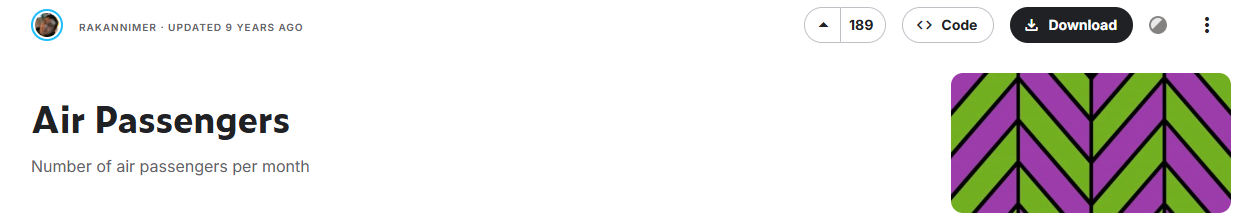

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------------- EDA image_load
import os
from PIL import Image
from tensorflow.keras.utils import load_img, image_dataset_from_directory, img_to_array

from sklearn.model_selection import train_test_split                   
#-----------------------------------------------------------------------------------  ML 모델
from sklearn.tree import DecisionTreeClassifier 
#----------------------------------------------------------------------------------   DL 모델
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D   # CNN관련
from tensorflow.keras.layers import Dense, Flatten, Rescaling                   # 일반 DL관련
from tensorflow.keras.initializers import GlorotNormal #Xavier
from tensorflow.keras.applications import MobileNetV2  #최소 이미지 크기 (32*32)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
#----------------------------------------------------------------------------------  평가
# from sklearn.metrics  import accuracy_score,      f1_score         -- 내부적으로 판단하므로 평가 (X)

import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)



# =========================================================================================

import warnings
warnings.filterwarnings('ignore')


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# <b> DATA load

In [2]:
df = pd.read_csv('./Airpassengers/AirPassengers.csv')
df.head(2)

,Month,#Passengers
0,1949-01,112
1,1949-02,118


In [3]:
df = pd.read_csv('./Airpassengers/AirPassengers.csv', parse_dates=["Month"])
df.columns = ["rdate","cnt"]
#df["rdate"] = pd.to_datetime(df["rdate"]).dt.strftime("%Y-%m") - 문자열로 바뀌기 땜시 사용안함
df.head(2)


,rdate,cnt
0,1949-01-01,112
1,1949-02-01,118


# EDA

In [4]:
df = df.set_index("rdate")
df.head(2)

,cnt
rdate,
1949-01-01,112
1949-02-01,118


In [5]:
df.index.min(),df.index.max()

(Timestamp('1949-01-01 00:00:00'), Timestamp('1960-12-01 00:00:00'))

<Figure size 640x480 with 0 Axes>

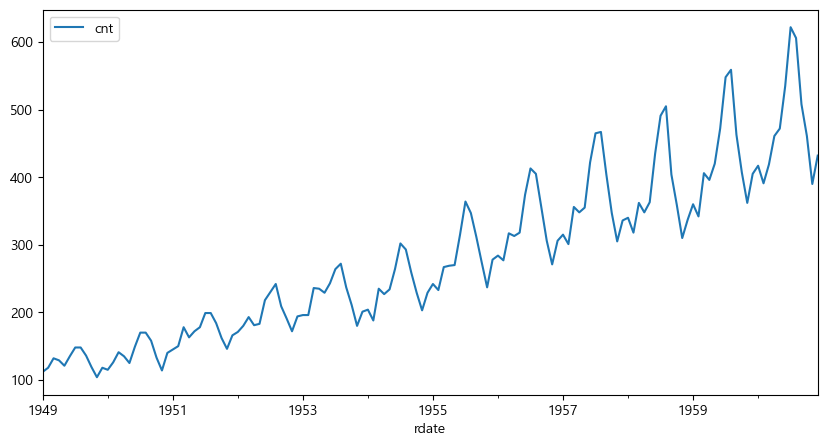

In [6]:
plt.figure()
df.plot(figsize=(10,5))  
plt.show();

# <b>전처리 & 가공

* <font color=red><b>정상성 데이터(Stationary)</b></font>
    - 평균, 분산이 시간에 관계없이 일정한 데이터로 통계적으로 안정적
    - 예측이나 모델링이 용이(주식의 일별 수익률)
* <font color=red><b>비정상성 --> 정상성
    - 평균 : 이동평균(MA:Moving Average), 차분(Difference)
    - 분산 : 스케일링(MinMax), 로그변환(값이양수인경우)

# 차분(Difference)

In [7]:
df['diff1'] = df['cnt'].diff(1) #이전 레코드와 비교
df['diff1'] = df['diff1'].bfill() #결측 채우기
df.head()

,cnt,diff1
rdate,,
1949-01-01,112,6.0
1949-02-01,118,6.0
1949-03-01,132,14.0
1949-04-01,129,-3.0
1949-05-01,121,-8.0


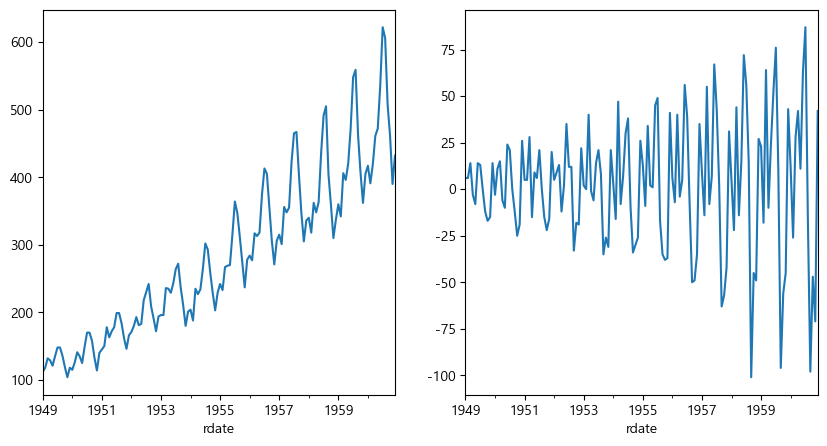

In [8]:
plt.figure()
plt.subplot(1,2,1)
df['cnt'].plot(figsize=(10,5))  

plt.subplot(1,2,2)
df['diff1'].plot(figsize=(10,5))  
  
plt.show();

# 이동평균(MA)
* 5일(w), 20일(m), 60일(q), 120(2q:상하반기), 200일(y)

분산 없애려고 이동평균구함

In [9]:
df['ma5'] = df['cnt'].rolling(5).mean()
df['ma20'] = df['cnt'].rolling(20).mean()
df.head()

,cnt,diff1,ma5,ma20
rdate,,,,
1949-01-01,112,6.0,NaN,NaN
1949-02-01,118,6.0,NaN,NaN
1949-03-01,132,14.0,NaN,NaN
1949-04-01,129,-3.0,NaN,NaN
1949-05-01,121,-8.0,122.4,NaN


## 결측 채우기 :앞/뒤 값으로 채우기
<pre><font color=red><b>df['컬럼'] = df['컬럼'].ffill() : 앞값으로 채우기
df['컬럼'] = df['컬럼'].bfill() : 뒤값으로 채우기</font color=red></b>

inplace=True XXXXXXXXXXXXXXXXXXXXXXXXXX
시계열 데이터는 보통 앞뒤값의 평균으로 채움

In [10]:
df['ma5'] = df['ma5'].bfill()
df['ma20'] = df['ma20'].bfill()
df.head(6)

,cnt,diff1,ma5,ma20
rdate,,,,
1949-01-01,112,6.0,122.4,132.55
1949-02-01,118,6.0,122.4,132.55
1949-03-01,132,14.0,122.4,132.55
1949-04-01,129,-3.0,122.4,132.55
1949-05-01,121,-8.0,122.4,132.55
1949-06-01,135,14.0,127.0,132.55


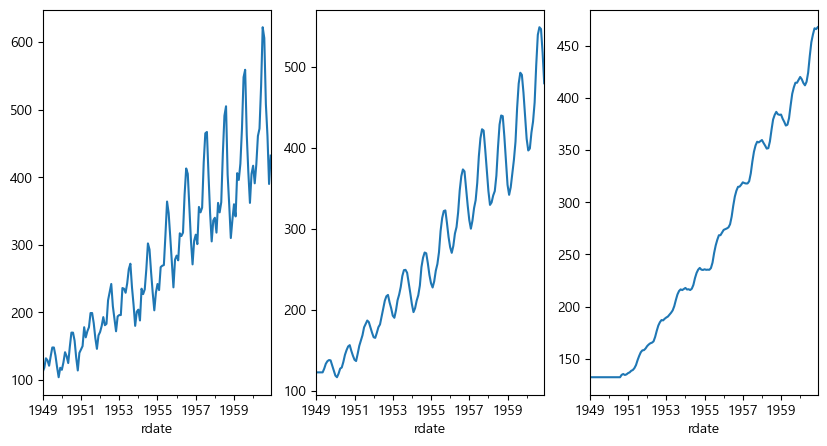

In [11]:
plt.figure()
plt.subplot(1,3,1)
df['cnt'].plot(figsize=(10,5))  

plt.subplot(1,3,2)
df['ma5'].plot(figsize=(10,5))  

plt.subplot(1,3,3)
df['ma20'].plot(figsize=(10,5))  
plt.show();

# 로그변환(값이양수인경우)

In [12]:
df['log'] = np.log1p(df['cnt'])
df.head()

,cnt,diff1,ma5,ma20,log
rdate,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388
1949-02-01,118,6.0,122.4,132.55,4.779123
1949-03-01,132,14.0,122.4,132.55,4.890349
1949-04-01,129,-3.0,122.4,132.55,4.867534
1949-05-01,121,-8.0,122.4,132.55,4.804021


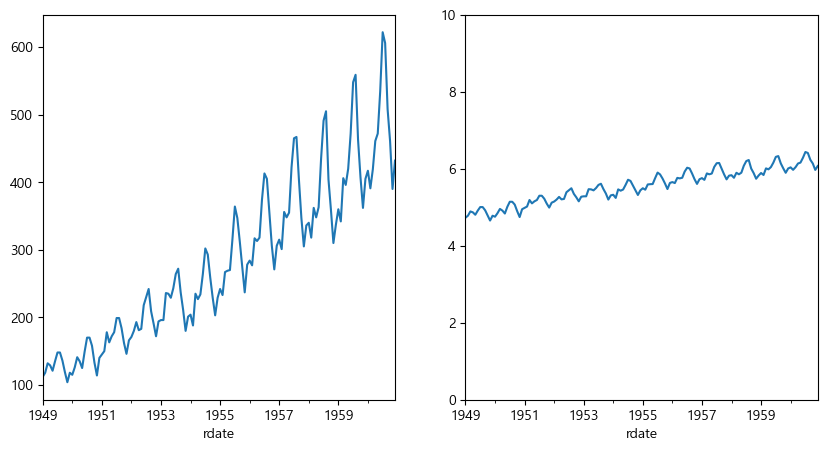

In [13]:
plt.figure()
plt.subplot(1,2,1)
df['cnt'].plot(figsize=(10,5))  

plt.subplot(1,2,2)
df['log'].plot(figsize=(10,5))  

plt.ylim(0,10) # y축고정 : 변동폭 사라짐
plt.show();

# 스케일링(MinMax)

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
res = scaler.fit_transform(df['cnt'].values.reshape(-1,1)) #스케일링할때 2차부터 가능
res [:5]

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853]])

In [15]:
df['scale'] = res.reshape(-1)
df.head(5)

,cnt,diff1,ma5,ma20,log,scale
rdate,,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388,0.015444
1949-02-01,118,6.0,122.4,132.55,4.779123,0.027027
1949-03-01,132,14.0,122.4,132.55,4.890349,0.054054
1949-04-01,129,-3.0,122.4,132.55,4.867534,0.048263
1949-05-01,121,-8.0,122.4,132.55,4.804021,0.032819


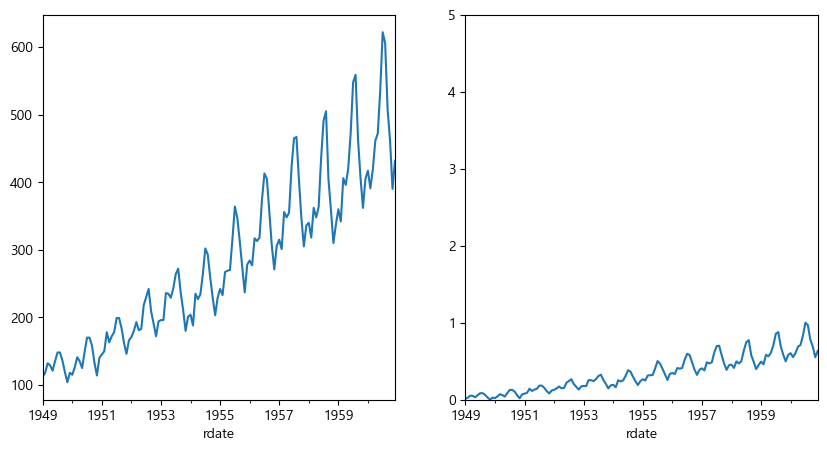

In [16]:
plt.figure()
plt.subplot(1,2,1)
df['cnt'].plot(figsize=(10,5))  

plt.subplot(1,2,2)
df['scale'].plot(figsize=(10,5))  

plt.ylim(0,5) # minmax는 값 범위 제한해서 0~1사이의 값으로 나와야함
plt.show();

## 정상성 데이터
* 평균(차분), 분산(log)

In [17]:
df['stat'] = np.log1p(df['cnt'])
df['stat'] = df['stat'].diff(1)
df['stat'] = df['stat'].bfill()
df.head(2)

,cnt,diff1,ma5,ma20,log,scale,stat
rdate,,,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388,0.015444,0.051736
1949-02-01,118,6.0,122.4,132.55,4.779123,0.027027,0.051736


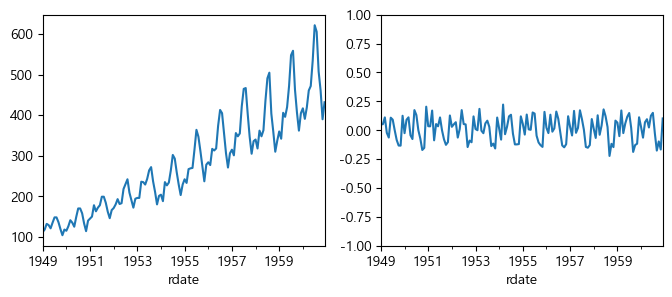

In [18]:
plt.figure()
plt.subplot(1,2,1)
df['cnt'].plot(figsize=(8,3))  

plt.subplot(1,2,2)
df['stat'].plot(figsize=(8,3))  
plt.ylim(-1,1)
plt.show();

# --------------------------------

# <font color = red><b> 가설 & 유의 수준

<table><tr><Td><img src="https://mblogthumb-phinf.pstatic.net/MjAxOTA2MTdfNDYg/MDAxNTYwNzUwMTM1NzA0.49JWh_Q3vuC7apeZ0PcraCISbDUndRBPd99ltygM-KMg.59DOaEPcq41fY2X7-T5bf-8R7Dq1hu97Ba47qVn_Veog.PNG.igenius21c/%EC%9C%A0%EC%9D%98%ED%99%95%EB%A5%A0_%EC%9C%A0%EC%9D%98%EC%88%98%EC%A4%80_3.png?type=w800" width=400></Td>
<Td>H0 : 귀무가설(일반적사실)<br>
H1 : 대립가설(연구자가 입증하려는 사실)<br>
유의수준(기각될수준:0.05) > 유의확률(p-value) : 기각영역 --> 귀무가설이 틀리다 (연구자 말이 맞다)<br>    
유의수준(기각될수준:0.05) < 유의확률(p-value) : 채택영역 --> 귀무가설이 맞다 (연구자 말이 틀리다)<br>    
</Td></tr>
</table>

# <font color = red><b> 확률 분포

| 이산형 확률 변수 (Discrete random variable)<br>0,1,2 | 예                      | 연속형 확률 변수 (Continuous random variable) <br>23.49 52.17| 예             |
| ------------------------------------ | ---------------------- | -------------------------------------- | ------------- |
| 베르누이 분포                              | 동전 1회 던져 앞면(1) / 뒷면(0) | 균일 분포 (Uniform)                        | 0~1 사이 난수     |
| 이항 분포                                | 동전 10번 던져 앞면 개수        | **정규 분포 (Normal)** <br><br><br>**표준 정규 분포 (Z)**                        | 사람 키, 시험 점수<br><b>평균m 편차n 종모양 좌우대칭 분포도<br><b>평균0 편차1 종모양 좌우대칭 분포도<br>$  Z = \frac{X - \mu}{\sigma} $   |
| 기하 분포                                | 첫 성공이 나올 때까지 시행 횟수     | 지수 분포 (Exponential)                    | 고객 도착 간격 시간   |
| 다항 분포                                | 주사위 여러 번 던져 각 눈 개수     | <b>t-분포                                   | 표본평균 검정<br>$ t = \frac{\bar{x} - \mu}{s/\sqrt{n}} $       |
| 포아송 분포                               | 1시간 동안 콜센터 전화 수        | <b>카이제곱 분포 (χ²)                           | 분산 검정, 적합도 검정<br>$ \chi^2 = \sum \frac{(O - E)^2}{E} $ |
|                                      |                        | <b>F-분포       | 2개집단분산 비교<br>$ F = \frac{s_1^2}{s_2^2} $  |
|                                      |                        | <b>ANOVA                                   | 3개 집단 이상 평균 비교<br>$ F = \frac{MS_{between}}{MS_{within}} $  |

<pre>
평균 :
    
중심극한의 정리 : 동전 10회 던져서 앞면이 나올 확률(t) --> 무한(30<=)히 던져서 앞면이 나올 확률(z)
t(1~2) : n < 30
Z(1)   : n >= 30
ANOVA(3)
    
분산 : F-분포, 카이제곱 

### Z
* https://ko.wikipedia.org/wiki/%ED%91%9C%EC%A4%80%EC%A0%95%EA%B7%9C%EB%B6%84%ED%8F%AC%ED%91%9C
* $  Z = \frac{X - \mu}{\sigma} $ 
<pre>시험성적
평균 : 70
표준편차 : 10
학생점수(x) : 85

In [19]:
z = (85-70) / 10
z # 표준정규분표포의 면적(확률) : 0.93319

1.5

### t
* https://ko.wikipedia.org/wiki/T%EB%B6%84%ED%8F%AC%ED%91%9C
* $ t = \frac{\bar{x} - \mu}{s/\sqrt{n}} $
* 모집단의 표준편차 모름
* 꼬리가 두껍다, z분포와 거의 비슷하다
<pre>시험성적
학생 수 : 16
A집단평균 : 70
B집단평균 : 85
샘플 표준편차 : 10

In [20]:
t = (85-70) / (10/4)
t #분포도 0.718

6.0

### 카이제곱
* https://en.wikipedia.org/wiki/Chi-squared_distribution
* $ \chi^2 = \sum \frac{(O - E)^2}{E} $
* <b>분산 검정
* <b>적합도 검정 : 특정 확률분포가 이론상의 확률분포와 얼마나 잘 맞는지 검정

<pre>
           실제 (%)      확률 (%)

동전 앞       40        50
동전 뒤       60        50

In [21]:
앞 = ((40-50)**2) /50
뒤 = ((60-50)**2) /50
카이제곱 = 앞 + 뒤
카이제곱 #0.71

4.0

### f
* $ F = \frac{s_1^2}{s_2^2} $
* 분산비율

<pre>
A분산 : 25
B분산 : 10

In [22]:
F =  25/10
F 

2.5

### ANOVA(평균차이를 분산으로 측정) == F
* 3개집단 이상 평균비교
* $ F = \frac{MS_{between}}{MS_{within}} $
* $SS_{between} = \sum n_i(\bar{x_i} - \bar{x})^2$ : 집단간 분산, 각 집단 평균이 전체 평균에서 얼마나 떨어져있는지
* $SS_{within} = \sum \sum (x_{ij} - \bar{x_i})^2$ : 집단 내 분산, 각 집단 내부 데이터가 집단 평균에서 얼마나 퍼져있는지<br>
* 집단 평균 차이가 크면 집단 간 분산이 커진다
* F가 클수록 집단 평균 차이가 큼
* F 작음 평균 차이 없음

<pre>
A = [65,70,75]
B = [70,75,80]
C = [78,82,86]

In [23]:
A = [65, 70, 75]
B = [70, 75, 80]
C = [78, 82, 86]

groups = [A, B, C]

mean_A = sum(A) / len(A)
mean_B = sum(B) / len(B)
mean_C = sum(C) / len(C)

grand_mean = (sum(A) + sum(B) + sum(C)) / (len(A) + len(B) + len(C))

ss_between = len(A) * (mean_A - grand_mean)**2 \
+ len(B) * (mean_B - grand_mean)**2 \
+ len(C) * (mean_C - grand_mean)**2

ss_within = sum((x - mean_A)**2 for x in A) \
+ sum((x - mean_B)**2 for x in B) \
+ sum((x - mean_C)**2 for x in C)

df_between = 3 - 1
df_within = 9 - 3

ms_between = ss_between / df_between
ms_within = ss_within / df_within

F = ms_between / ms_within

print("A 평균 =", mean_A)
print("B 평균 =", mean_B)
print("C 평균 =", mean_C)
print("전체평균 =", grand_mean)

print("SS_between =", ss_between)
print("SS_within =", ss_within)

print("df_between =", df_between)
print("df_within =", df_within)

print("MS_between =", ms_between)
print("MS_within =", ms_within)

print("F =", F)

A 평균 = 70.0
B 평균 = 75.0
C 평균 = 82.0
전체평균 = 75.66666666666667
SS_between = 218.0
SS_within = 132.0
df_between = 2
df_within = 6
MS_between = 109.0
MS_within = 22.0
F = 4.954545454545454


| 상황       | 검정          | 분포 | 핵심         |
| -------- | ----------- | -- | ---------- |
| 평균 1개    | 단일표본 t-test | t  | 표본평균 vs 기준 |
| 평균 2개    | 독립표본 t-test | t  | 두 집단 평균    |
| 평균 3개 이상 | ANOVA       | F  | 여러 집단 평균   |
| 범주형 관계   | 카이제곱        | χ² | 변수 독립성     |
| 분산 비교    | F-test      | F  | 분산 비교      |


# <b><font color = red>통계 검정
* 귀무가설 --> 유의수준(0.05) --> 확률분포계산 --> 통계검정 --> 기각/채택
-----
* 독립성검정 : 상관분석(상관계수, 공분산)
* 적합성검정 : 카이제곱(등분산/이분산)
* 정규성검정 : 확률분포,유의수준(StandardScaler(Z==평균 0, 편차 1))
* 정상성검정 : ADF KPSS(로그, 스케일링, 차분) 평균,편차 평활화

## 데이터 분포도 시각화

 - 시계열 도표(Time Series Plot)
 - ACF/PCAF 그래프(정상 시계열은 시차가 커짐에 따라 ACF가 빠르게 0으로 수렴)
 - 분포도 (Q-Q Polt , pairplot , Histogram, Scatter)

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드
sample_df = sns.load_dataset("mpg")

# 결측치 제거
sample_df = sample_df.dropna()
sample_df.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320


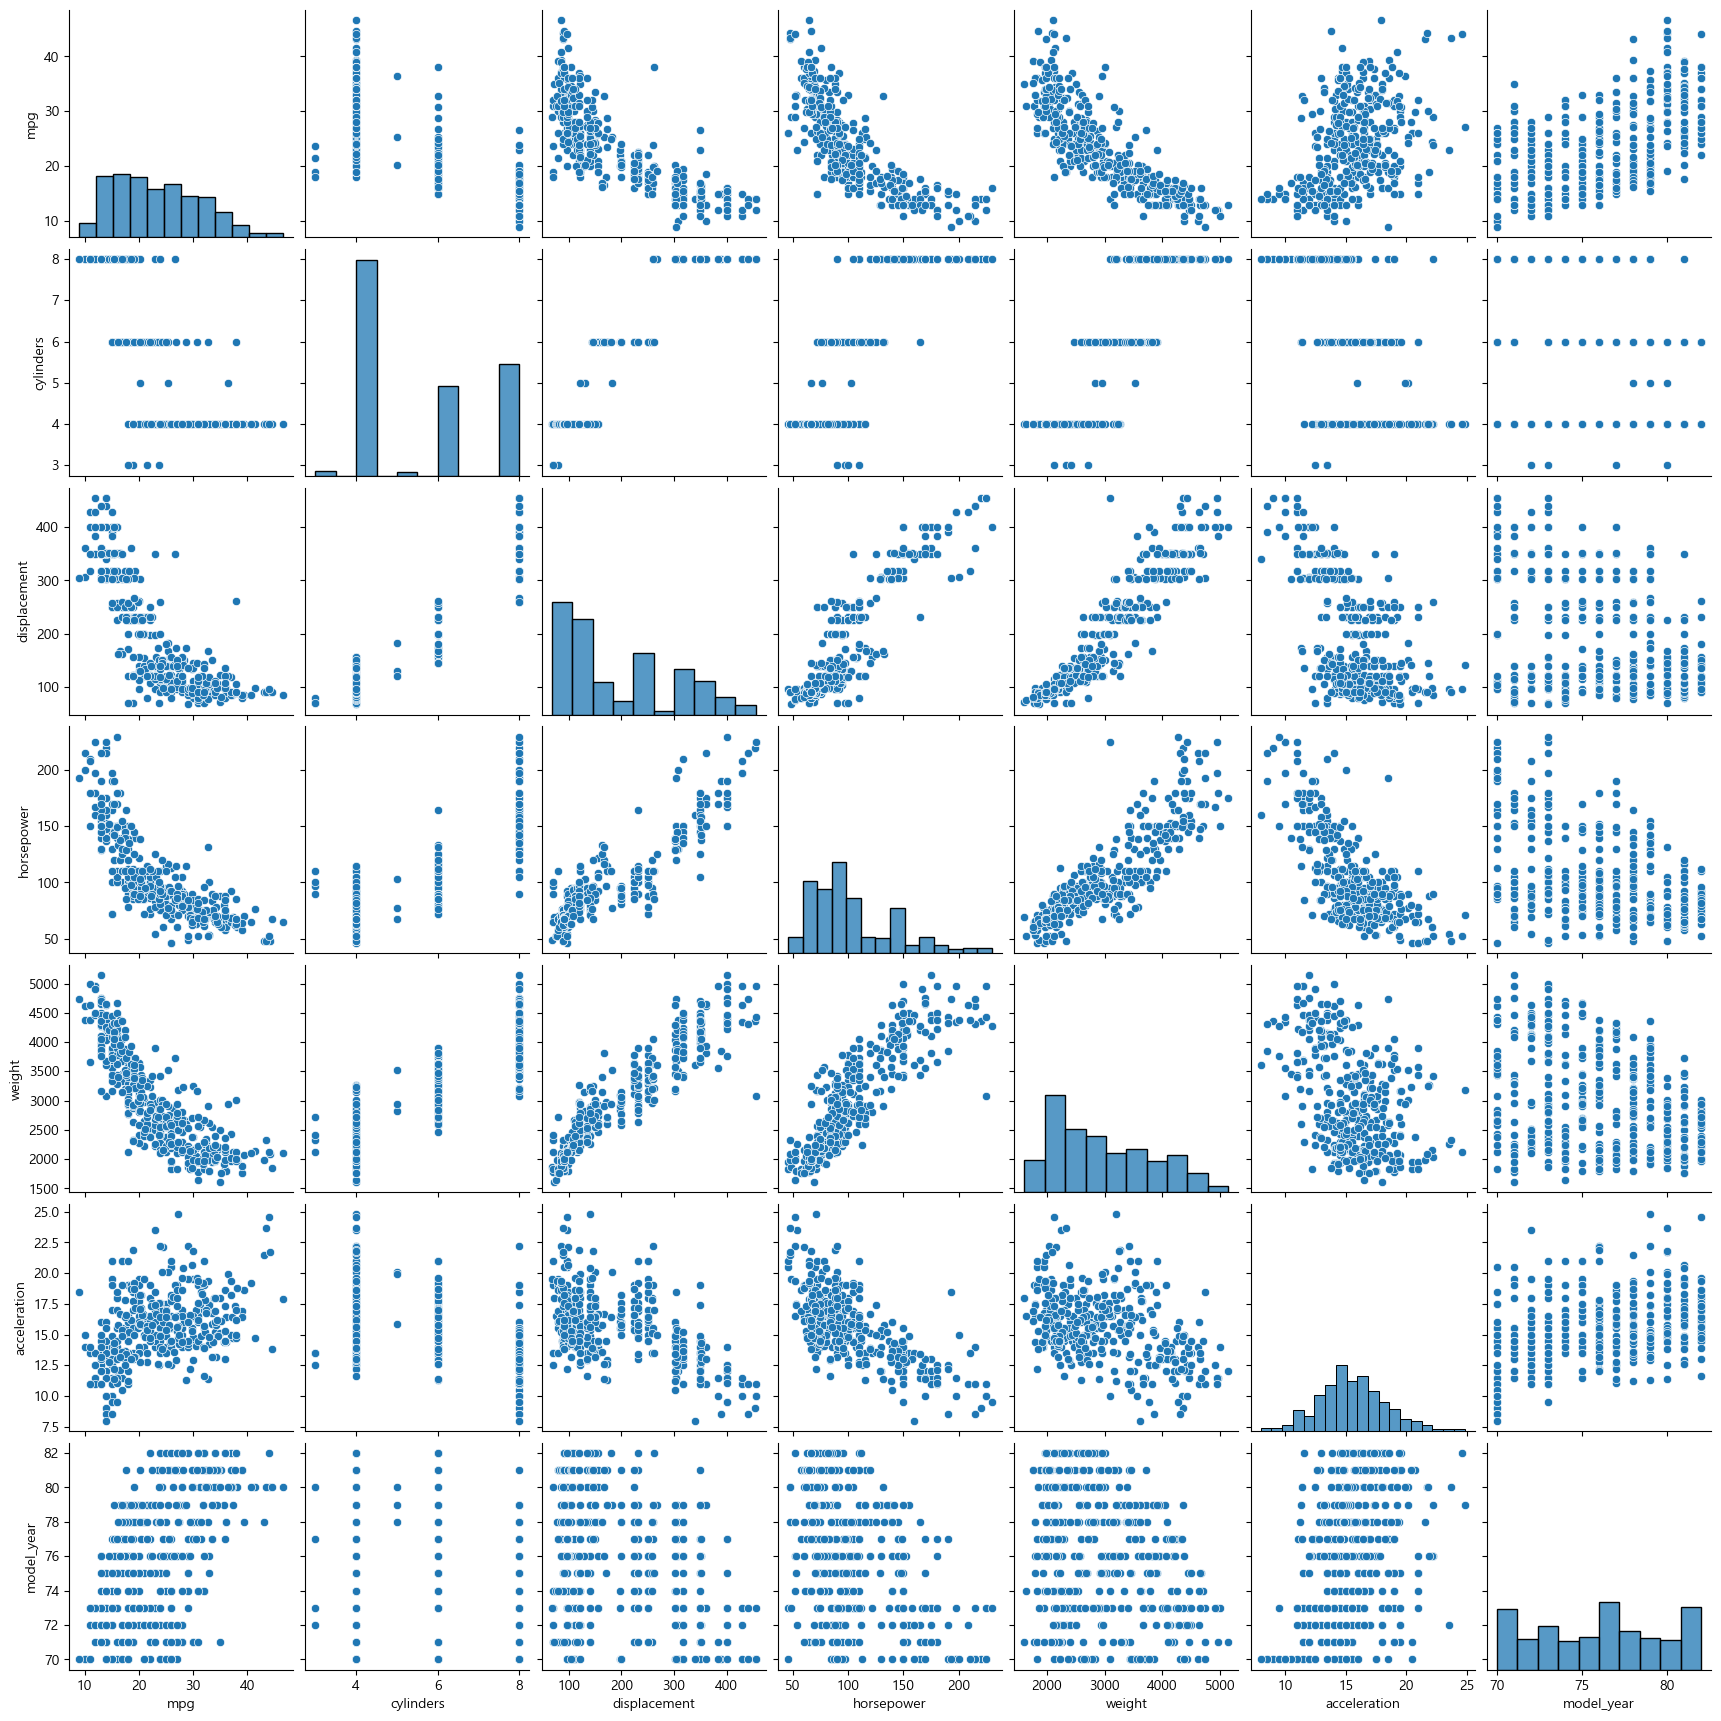

In [25]:
sns.pairplot(sample_df, diag_kind="hist")
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

def plt_show_3_graph(data):
    # 그래프 크기 설정
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 히스토그램
    sns.histplot(data, kde=True, ax=axes[0])
    axes[0].set_title('Histogram(정규성)')

    # QQ 플롯
    # sm.qqplot(data, line='45', ax=axes[1])
    stats.probplot(data, plot=axes[1])
    axes[1].set_title('Q-Q Plot(정상성)')

    plt.tight_layout()
    plt.show()

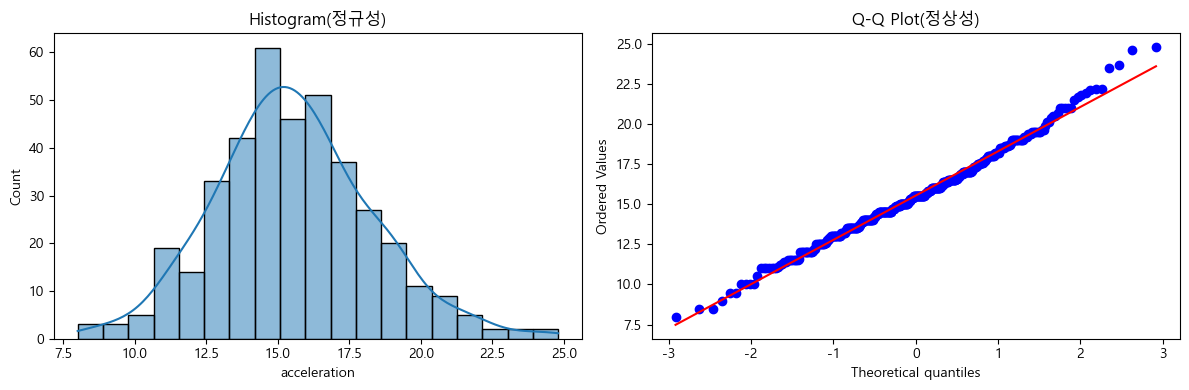

In [27]:
plt_show_3_graph (sample_df['acceleration'])

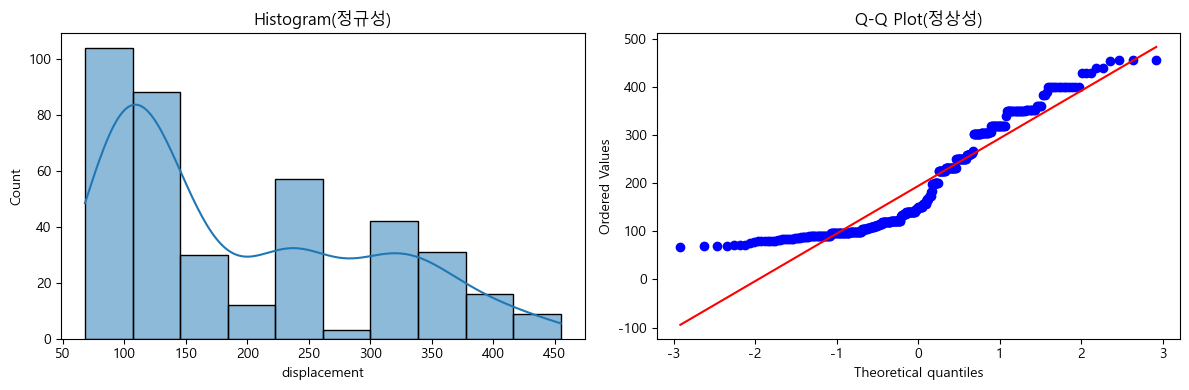

In [60]:
plt_show_3_graph (sample_df['displacement'])
# 비정규성, 비정상성

## <b>정상성 검정

 - ADF 검정 (Augmented Dickey-Fuller)
	- (H_0) : 데이터는 비정상성
	- p-value < 0.05 : 정상성으로 판단
 - KPSS 검정 (Kwiatkowski-Phillips-Schmidt-Shin)
	-  (H_0) : 데이터는 정상성
	- p-value > 0.05 : 정상성으로 판단
 - PP 검정 (Phillips-Perron)
	-  (H_0) : 데이터는 비정상성
	- p-value < 0.05 : 정상성으로 판단


In [29]:
#!pip install statsmodels pandas

In [30]:
df.columns
df.head(3)

Index(['cnt', 'diff1', 'ma5', 'ma20', 'log', 'scale', 'stat'], dtype='object')

,cnt,diff1,ma5,ma20,log,scale,stat
rdate,,,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388,0.015444,0.051736
1949-02-01,118,6.0,122.4,132.55,4.779123,0.027027,0.051736
1949-03-01,132,14.0,122.4,132.55,4.890349,0.054054,0.111226


In [31]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_test(x):
    x = pd.Series(x).dropna()

    adf_result = adfuller(x)
    print("[ADF]")
    #print("statistic :", adf_result[0])
    if adf_result[1] > 0.05 : 
        print("비정상성 p-value   :", adf_result[1])
    else :
        print("정상성 p-value   :", adf_result[1])
    #print("crit value:", adf_result[4])

    print()

    kpss_result = kpss(x, regression="c", nlags="auto")
    print("[KPSS]")
    #print("statistic :", kpss_result[0])
    print("p-value   :", kpss_result[1])
    if kpss_result[1] > 0.05 : 
        print("정상성 p-value   :", kpss_result[1])
    else :
        print("비정상성 p-value   :", kpss_result[1])
    print("crit value:", kpss_result[3])

stationarity_test(df["cnt"])

[ADF]
비정상성 p-value   : 0.991880243437641

[KPSS]
p-value   : 0.01
비정상성 p-value   : 0.01
crit value: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\PC\AppData\Local\Temp\ipykernel_19088\567031824.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(x, regression="c", nlags="auto")


In [32]:
stationarity_test(df["stat"]) 

[ADF]
비정상성 p-value   : 0.07907516260311181

[KPSS]
p-value   : 0.1
정상성 p-value   : 0.1
crit value: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\PC\AppData\Local\Temp\ipykernel_19088\567031824.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(x, regression="c", nlags="auto")


## <b>정규성 검정

 - 샤피로-윌크 (Shapiro-Wilk) 
	- 일반적으로 n<50 소규모 데이터
	-  (H_0) : 데이터는 정규분포
	- p-value > 0.05 : 정규분포로 판단
 - 콜모고로프-스미르노프 (K-S) 
	- 일반적으로 n>=50 대규모 데이터
	-  (H_0) : 데이터는 정규분포
	- p-value > 0.05 : 정규분포로 판단

In [33]:
from scipy.stats import shapiro, kstest
import pandas as pd

def normality_test(x):
    x = pd.Series(x).dropna()

    shapiro_result = shapiro(x)
    print("[Shapiro-Wilk]")
    #print("statistic :", shapiro_result[0])
    if shapiro_result[1] > 0.05 : 
        print("정규분포 p-value   :", shapiro_result[1])
    else :
        print("정규분포XX p-value   :", shapiro_result[1])

    print()

    ks_result = kstest(x, "norm", args=(x.mean(), x.std()))
    print("[Kolmogorov-Smirnov]")
    #print("statistic :", ks_result[0])
    print("p-value   :", ks_result[1])
    if ks_result[1] > 0.05 : 
        print("정규분포 p-value   :", ks_result[1])
    else :
        print("정규분포XX p-value   :", ks_result[1])

In [34]:
normality_test(df["cnt"])

[Shapiro-Wilk]
정규분포XX p-value   : 6.832415574230731e-05

[Kolmogorov-Smirnov]
p-value   : 0.09747351318890995
정규분포 p-value   : 0.09747351318890995


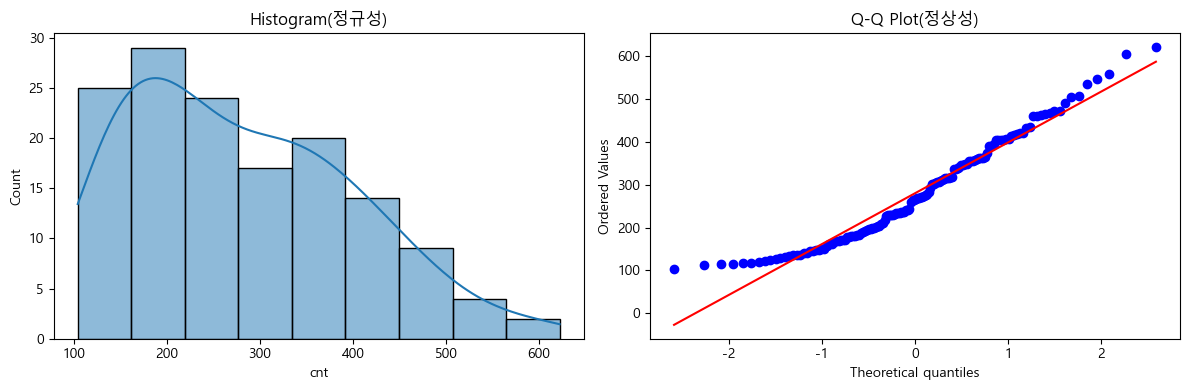

In [35]:
plt_show_3_graph(df["cnt"])

In [36]:
stationarity_test(df["stat"]) 

[ADF]
비정상성 p-value   : 0.07907516260311181

[KPSS]
p-value   : 0.1
정상성 p-value   : 0.1
crit value: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\PC\AppData\Local\Temp\ipykernel_19088\567031824.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(x, regression="c", nlags="auto")


In [37]:
normality_test(df["stat"])

[Shapiro-Wilk]
정규분포XX p-value   : 0.0019869405651398793

[Kolmogorov-Smirnov]
p-value   : 0.351433319073157
정규분포 p-value   : 0.351433319073157


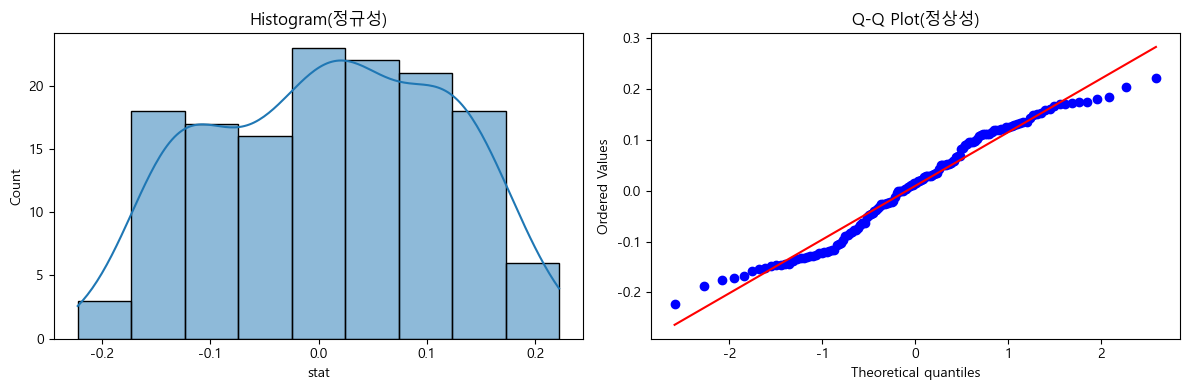

In [38]:
plt_show_3_graph(df["stat"])

## <b> 양측검정 vs. 단측검정

* 단측검정
   - 귀무가설 : 평균 >= 170
   - (170)_________
* 양측검정
   - 귀무가설 : 평균 == 170
   - __________ (170)_________

<img src = "http://infoso.kr/wp/wp-content/uploads/2020/10/%EC%A0%95%EA%B7%9C%EB%B6%84%ED%8F%AC2-1020x574.png" width="700">

<img src = "https://static.wikidocs.net/images/page/198387/%EB%8B%A8%EC%B8%A1%EA%B2%80%EC%A0%95_%EC%96%91%EC%B8%A1%EA%B2%80%EC%A0%95.png" width = "800">

# --------------------------------

# <b><font color = red> ARIMA

In [39]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

| 구분                                          | 수식                                                            | 의미                   | 특징               |
| ------------------------------------------- | -------------------------------------------------------------- | -------------------- | ---------------- |
| **ACF** (Autocorrelation Function)          | $ \rho_k = \dfrac{Cov(X_t , X_{t-k})}{Var(X_t)} $               | 시계열과 k시차 값 사이 상관계수   | 직접 + 간접 영향 모두 포함 |
| **PACF** (Partial Autocorrelation Function) | $\phi_{kk} = Corr(X_t , X_{t-k} \mid X_{t-1},...,X_{t-k+1})$  | 중간 lag 영향을 제거한 순수 상관 | 직접 영향만 측정       

| 항목        | ACF       | PACF      |
| --------- | --------- | --------- |
| 측정 관계     | 전체 상관     | 순수 상관     |
| 중간 lag 영향 | 포함        | 제거        |
| <font color = red><b>MA 모델     | <font color = red><b>q(차수) 이후 절단   | 천천히 감소    |
| <font color = red><b>AR 모델     | 천천히 감소    | <font color = red><b>p(차수) 이후 절단   |
| ARMA 모델   | 둘 다 점진 감소 | 둘 다 점진 감소 |
* <font color = red><b> MA(q) AR(p)
* <font color = red><b> ARIMA(p, d, q)
* <font color = red><b> p, q = 자기 상관을 확인하기 위한 차수
* <font color = red><b> d = 정상성을 확인하기 위한 차수
---------
<pre>
* 분산 : 1개 피쳐 .. 평균으로 부터 얼마나 떨어져 있는지                    | 편차(데이터 - 평균)의 제곱의 평균
* 공분산 : 2개 피쳐 .. 평균으로 부터 얼마나 떨어져 있는지                  | 두 변수의 각 편차를 서로 곱한 값의 평균
* 상관계수 : 공분산/2개피쳐 표준편차(-1 ~ 1) 대각선(분산), 나머지(공분산)  | 공분산을 두 변수의 표준편차의 곱으로 나눈다
* 자기상관 : 1개 피쳐(At, At-1)                                           | 특정 시차($k$)만큼 떨어진 동일 변수 간의 상관계수

In [40]:
df = df.asfreq("MS")
df.head(2)

,cnt,diff1,ma5,ma20,log,scale,stat
rdate,,,,,,,
1949-01-01,112,6.0,122.4,132.55,4.727388,0.015444,0.051736
1949-02-01,118,6.0,122.4,132.55,4.779123,0.027027,0.051736


## <b><font color=red>차분 - 정상성(d=1) : 계절성, 추세를 없애기위해

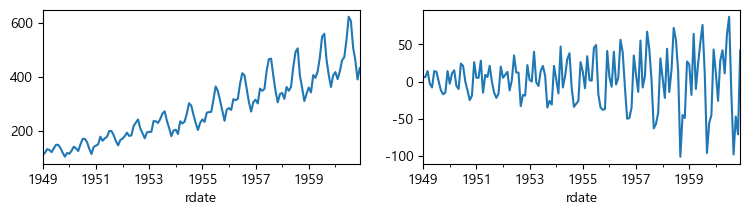

In [41]:
plt.figure()

plt.subplot(1,2,1)
df['cnt'].plot(figsize=(9,2))

plt.subplot(1,2,2)
df['diff1'].plot(figsize=(9,2))

plt.show();

* <b>강한 추세(trend)와 계절성(seasonality)을 보인다

## <font color=red><b>ACF(q)/PACF(p) - 자기상관(p,q) : 이전데이터가 다음 데이터 영향을 준다
* https://www.statsmodels.org/stable/index.html
* https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html#statsmodels.graphics.tsaplots.plot_acf

``` python
statsmodels.graphics.tsaplots.plot_acf(x, ax=None, lags=None, *, alpha=0.05, use_vlines=True, adjusted=False, fft=False, missing='none', title='Autocorrelation', zero=True, auto_ylims=False, bartlett_confint=True, vlines_kwargs=None, **kwargs)

statsmodels.graphics.tsaplots.plot_pacf(x, ax=None, lags=None, alpha=0.05, method='ywm', use_vlines=True, title='Partial Autocorrelation', zero=True, vlines_kwargs=None, **kwargs)

class statsmodels.tsa.arima.model.ARIMA(endog, exog=None, order=(0, 0, 0), seasonal_order=(0, 0, 0, 0), trend=None, enforce_stationarity=True, enforce_invertibility=True, concentrate_scale=False, trend_offset=1, dates=None, freq=None, missing='none', validate_specification=True)

<b> ACF / PACF 전체 정리표
| 구분       | ACF            | PACF          |
| -------- | -------------- | ------------- |
| 의미       | 자기상관함수         | 편자기상관함수       |
| 상관관계     | 직접 + 간접        | 직접 관계만        |
| 보는 관계    | y(t) vs y(t-k) | 중간 영향 제거 후 상관 |
| lag 의미   | k시점 이전 데이터     | 동일            |
| 그래프      | lag별 상관계수      | lag별 순수 상관    |
| 사용 목적    | MA 차수 찾기       | AR 차수 찾기      |
| 찾는 파라미터  | q              | p             |
| 특징       | MA에서 q에서 끊김    | AR에서 p에서 끊김   |
| AR 모델 패턴 | 천천히 감소         | p에서 절단        |
| MA 모델 패턴 | q에서 절단         | 천천히 감소        |


* <font color = red><b>자기상관확인(lags=40)

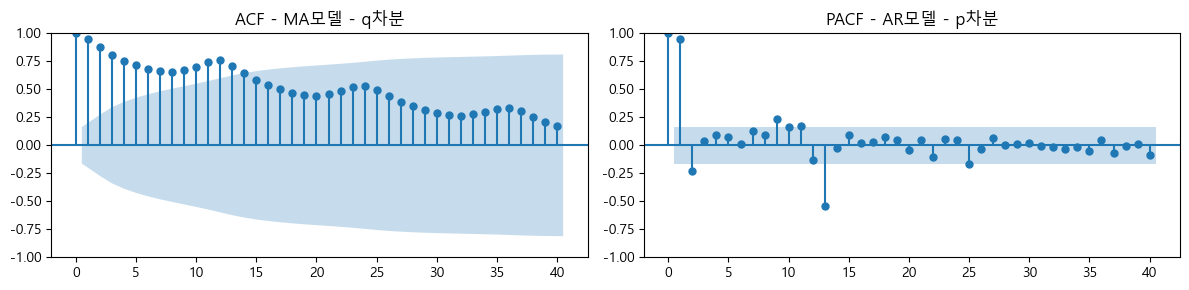

In [42]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. 기존에 떠 있는 모든 창을 닫고 시작
plt.close('all')

# 2. subplots 생성
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# 3. 핵심: 결과값을 변수(_)에 담아서 중복 출력을 강제로 차단합니다.
_ = plot_acf(df['cnt'], lags=40, ax=axes[0], title='ACF - MA모델 - q차분')
_ = plot_pacf(df['cnt'], lags=40, ax=axes[1], title='PACF - AR모델 - p차분')

# 4. 레이아웃 정돈 후 출력
plt.tight_layout()
plt.show()

# fig, axes = plt.subplots(1, 2, figsize=(12,3))

# plot_acf(df['cnt'] , lags=36, ax=axes[0] , title='ACF - MA모델 - q차분')
# plot_pacf(df['cnt'], lags=36, ax=axes[1] , title='PACF - AR모델 - p차분')

# plt.show()

In [43]:
df.index.max()

Timestamp('1960-12-01 00:00:00')

In [44]:
model = ARIMA(df['cnt'][:-12] ,  order=(1, 1, 0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)   #12개월 예측  ---  24(시) 30(일) 12(월) 4(분기)
forecast

1960-01-01    417.522421
1960-02-01    421.169189
1960-03-01    422.231198
1960-04-01    422.540475
1960-05-01    422.630542
1960-06-01    422.656772
1960-07-01    422.664410
1960-08-01    422.666635
1960-09-01    422.667283
1960-10-01    422.667471
1960-11-01    422.667526
1960-12-01    422.667542
Freq: MS, Name: predicted_mean, dtype: float64

In [45]:
df['cnt'][-12:]

rdate
1960-01-01    417
1960-02-01    391
1960-03-01    419
1960-04-01    461
1960-05-01    472
1960-06-01    535
1960-07-01    622
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: cnt, dtype: int64

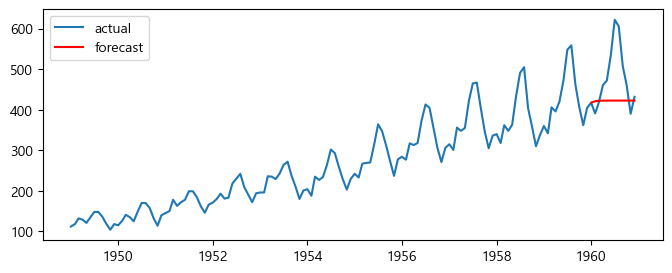

In [46]:
plt.figure(figsize=(8,3))

plt.plot(df['cnt'], label="actual")
plt.plot(forecast, label="forecast", color="red")

plt.legend()
plt.show();

# <b>SARIMAX

In [47]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df['cnt'][:-12], order=(1,1,0), seasonal_order=(1,1,0,12))
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)

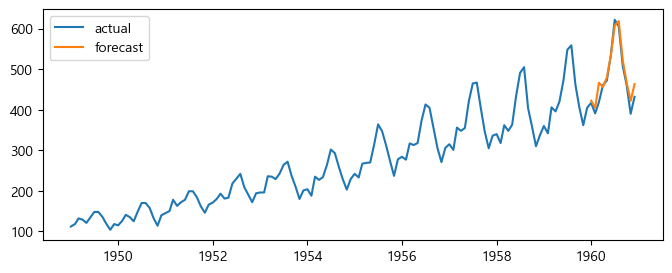

In [48]:
plt.figure(figsize=(8,3))
plt.plot(df['cnt'], label="actual")
plt.plot(forecast, label="forecast")
plt.legend()
plt.show();

* lag가 강함 - 현재 값이 과거 값과 강하게 연결되어 있다

# <font color = red><b>딥러닝 LSTM

<img src = "https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fb6kVlm%2Fbtq4Cs5VOPX%2FAAAAAAAAAAAAAAAAAAAAAMYQoJiEudo_8wyGznteHfaLNELmur5pNYm9-sjkzJMG%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3D3p5ZsREruPh0ibYMuTxdC0vR1nw%253D" width = "500">

In [49]:
df = pd.read_csv("./Airpassengers/AirPassengers.csv", parse_dates=["Month"])
df.columns = ["rdate", "cnt"]
df = df.set_index("rdate")
df.head(2)

,cnt
rdate,
1949-01-01,112
1949-02-01,118


# 윈도우 슬라이딩
* 시계열 데이터를 일정 길이 묶음으로 잘라서 학습 데이터로 만드는 방법

<img src= "https://images.velog.io/images/findingflow/post/088196e2-54ae-4d82-a2a3-7c3110545fca/image.png" >

* <font color=red><b>1차 : 데이터:11개 , 윈도우사이즈:6 , 루프:5

In [50]:
arr = np.arange(11)
arr

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [51]:
window_size = 6
X = []
y = []

for a in range(len(arr) - window_size):
    X.append(arr[a : a+window_size])
    y.append(arr[a+window_size])
print(np.array(X))
print(np.array(y))
print()

[[0 1 2 3 4 5]
 [1 2 3 4 5 6]
 [2 3 4 5 6 7]
 [3 4 5 6 7 8]
 [4 5 6 7 8 9]]
[ 6  7  8  9 10]



* <font color=red><b>2차 arr : 데이터:11개 , 윈도우사이즈:6 , 루프:5

In [52]:
arr = np.arange(11).reshape(-1,1)
arr[:3], arr.shape

(array([[0],
        [1],
        [2]]),
 (11, 1))

In [53]:
window_size = 6

X = []
y = []

for a in range(len(arr) - window_size):
    X.append(arr[a : a + window_size, 0])
    y.append(arr[a + window_size, 0])
    
print(np.array(X))
print(np.array(y))

[[0 1 2 3 4 5]
 [1 2 3 4 5 6]
 [2 3 4 5 6 7]
 [3 4 5 6 7 8]
 [4 5 6 7 8 9]]
[ 6  7  8  9 10]


* <font color=red><b>3차 dataframe : 데이터:11개 , 윈도우사이즈:6 , 루프:5

In [54]:
arr = np.arange(11).reshape(-1,1)
arr_df = pd.DataFrame(arr)
arr_df.head(3)

,0
0,0
1,1
2,2


In [55]:
window_size = 6

X = []
y = []

for i in range(len(arr_df) - window_size):
    X.append(arr_df.iloc[i:i+window_size, 0])
    y.append(arr_df.iloc[i+window_size, 0]) #뒤에 0찍는거 열ㅋㅋ

print( np.array(X) )
print( np.array(y) )

[[0 1 2 3 4 5]
 [1 2 3 4 5 6]
 [2 3 4 5 6 7]
 [3 4 5 6 7 8]
 [4 5 6 7 8 9]]
[ 6  7  8  9 10]


## <b> 전처리 & 가공

* 정상성 변환

In [56]:
df['cnt'] = np.log1p(df['cnt']) #분산안정화 -> 증가 속도 완만
df['cnt'] = df['cnt'].diff(1) #차분 -> 평균 일정
df['cnt'] = df['cnt'].bfill #1차분이라 1번째 레코드 결측 -> 결측채우기
df.head(2)

,cnt
rdate,
1949-01-01,0.051736
1949-02-01,0.051736


* 윈도우 슬라이딩

In [57]:
window_size = 12 #과거 12개월 데이터 사용

X = []
y = []

for i in range(len(df) - window_size):
    X.append( df.iloc[a : a+window_size, 0] ) # a ~ a+11까지 12개 데이터
    y.append( df.iloc[a+window_size, 0]     ) # 12개월 다음 값
    
X = np.array(X) #LSTM은 numpy/tensor입력
y = np.array(y)

print( X.shape , X[:3])
print( y.shape , y[:5] )

(132, 12) [[-0.06351341  0.10863384  0.09129142  0.         -0.08396538 -0.13248918
  -0.13353139  0.12516314 -0.0255333   0.0905969   0.11163997 -0.04317217]
 [-0.06351341  0.10863384  0.09129142  0.         -0.08396538 -0.13248918
  -0.13353139  0.12516314 -0.0255333   0.0905969   0.11163997 -0.04317217]
 [-0.06351341  0.10863384  0.09129142  0.         -0.08396538 -0.13248918
  -0.13353139  0.12516314 -0.0255333   0.0905969   0.11163997 -0.04317217]]
(132,) [-0.07637298 -0.07637298 -0.07637298 -0.07637298 -0.07637298]


## <b>LSTM 모델
* https://keras.io/api/layers/recurrent_layers/lstm/

``` python
keras.layers.LSTM(
    units,
    activation="tanh",
    recurrent_activation="sigmoid",
    use_bias=True,
    kernel_initializer="glorot_uniform",
    recurrent_initializer="orthogonal",
    bias_initializer="zeros",
    unit_forget_bias=True,
    kernel_regularizer=None,
    recurrent_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    recurrent_constraint=None,
    bias_constraint=None,
    dropout=0.0,
    recurrent_dropout=0.0,
    seed=None,
    return_sequences=False,
    return_state=False,
    go_backwards=False,
    stateful=False,
    unroll=False,
    use_cudnn="auto",
    **kwargs
)

### <font color=red size=7><b>input_shape : 3D
* samples : 데이터 갯수
* timestep : window_size
* features : 변수갯수 == df['cnt']

In [58]:
print( X.shape )
print( X.reshape(132, 12, 1).shape )
print( X.reshape(X.shape[0], X.shape[1], 1) .shape )

X = X.reshape(X.shape[0], X.shape[1], 1)

(132, 12)
(132, 12, 1)
(132, 12, 1)


## <b> 학습 & 평가

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(units=50,  activation='tanh' , input_shape=(window_size,1) ) ,   #12, 1개피쳐(cnt)
    Dense(units=1 )      #----- output layer   
 ]) 

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
from sklearn.model_selection import train_test_split
X80,X20,y80,y20 = train_test_split(X, y , test_size=0.2, shuffle=False)
X80.shape

(105, 12, 1)

In [63]:

model.compile(loss="mse" , optimizer="adam",  metrics=["mse"]) 
fit_res = model.fit(X80, y80,  epochs=20, validation_data=(X20, y20) )
loss,mse = model.evaluate(X20, y20)
print(f"loss:{loss:.4f} " )

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0042 - mse: 0.0042 - val_loss: 0.0012 - val_mse: 0.0012
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.6680e-04 - mse: 5.6680e-04 - val_loss: 1.6904e-04 - val_mse: 1.6904e-04
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.7881e-04 - mse: 4.7881e-04 - val_loss: 6.7851e-04 - val_mse: 6.7851e-04
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 4.7754e-04 - mse: 4.7754e-04 - val_loss: 6.8933e-05 - val_mse: 6.8933e-05
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.6544e-05 - mse: 2.6544e-05 - val_loss: 4.5929e-05 - val_mse: 4.5929e-05
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8.4036e-05 - mse: 8.4036e-05 - val_loss: 1.4338e-04 - val_mse: 1.4338e-04
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.3586e-04 - mse: 1.3586e-04 - val_loss: 8.5920e-05 - val_mse: 8.5920e-05
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 5.7718e-05 - mse: 5.7718e-05 - val_loss: 6

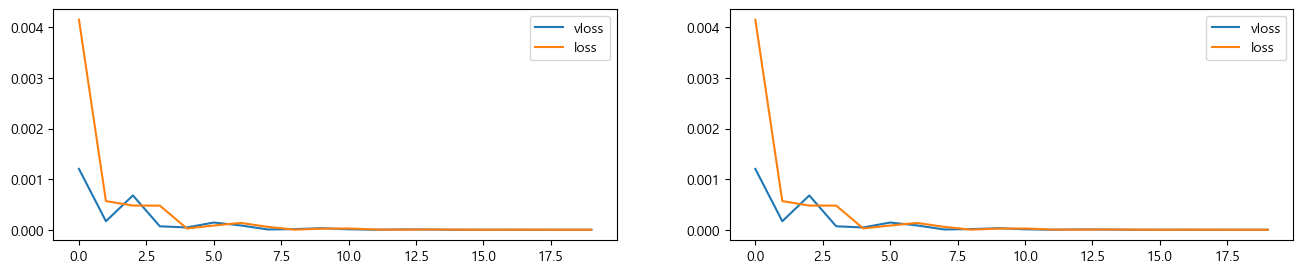

In [64]:
plt.figure(figsize=(16,3))
plt.subplot(1,2,1)
vloss = fit_res.history["val_loss"]
loss = fit_res.history["loss"]
plt.plot(range(20),vloss , label="vloss")
plt.plot(range(20),loss  , label="loss")
plt.legend()

plt.subplot(1,2,2)
vloss = fit_res.history["val_loss"]
loss = fit_res.history["loss"]
plt.plot(range(20),vloss , label="vloss")
plt.plot(range(20),loss  , label="loss")
plt.legend()
plt.show();